In [70]:
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

N_GAMES = 10000
EPISILON = 1e-6

# Seed 
random.seed(42)
np.random.seed(42)

### Assuming Player B picks same number as Player A but smaller

In [71]:
def game_rule(a, b, c):
    ### Looks at value a, b, c and returns (x, x, x) saying who pays who

    # In case there is equality between a, b, c, it wont affect the game play as since it happens very very rarely. 

    maxx = np.max([a, b, c])
    if a == maxx:
        return (-(b + c), b, c)
    elif b == maxx:
        return (a, -(a + c), c)
    elif c == maxx:
        return (a, b, (-a + b))
    else:
        raise Exception("Something went wrong. ")
    

In [72]:
GAME_HISTORY = {}

As = np.arange(0, 100, 0.5)

for a in tqdm(As):
    b = a - EPISILON

    payoutsA = []
    payoutsB = []
    payoutsC = []

    for _ in range(N_GAMES):
        c = random.uniform(0, 100)
        x, y, z = game_rule(a, b, c)

        payoutsA.append(x)
        payoutsB.append(y)
        payoutsC.append(z)

    GAME_HISTORY[a] = (np.mean(payoutsA), np.mean(payoutsB), np.mean(payoutsC))

        

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:21<00:00,  9.35it/s]


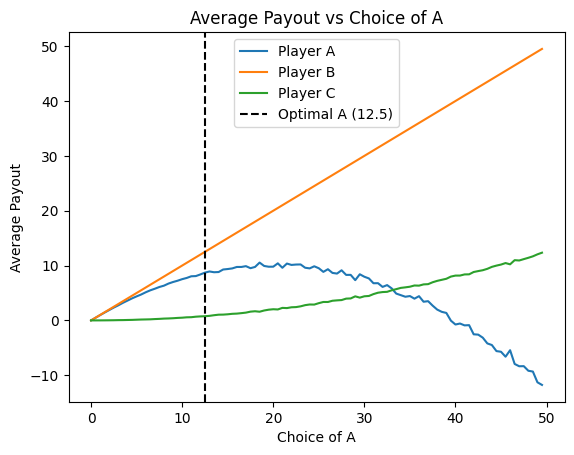

The value that gives the maximum payout to player A is 18.5


In [73]:
SHOW_FIRST_K_VALUES = 100

avg_payouts = np.array(list(GAME_HISTORY.values()))
a_values = list(GAME_HISTORY.keys())[:SHOW_FIRST_K_VALUES]

plt.plot(a_values, avg_payouts[:SHOW_FIRST_K_VALUES, 0], label="Player A")
plt.plot(a_values, avg_payouts[:SHOW_FIRST_K_VALUES, 1], label="Player B")
plt.plot(a_values, avg_payouts[:SHOW_FIRST_K_VALUES, 2], label="Player C")

# Add a vertical dashed black line at x=12.5
plt.axvline(x=12.5, color='k', linestyle='--', label="Optimal A (12.5)")

plt.xlabel("Choice of A")
plt.ylabel("Average Payout")
plt.title("Average Payout vs Choice of A")
plt.legend()
plt.show()

# Find the value the give maximum payout to player A
max_payout_a = np.max(avg_payouts[:, 0])
max_payout_a_index = np.where(avg_payouts[:, 0] == max_payout_a)[0][0]
max_payout_a_value = a_values[max_payout_a_index]

print(f"The value that gives the maximum payout to player A is {max_payout_a_value}")
